<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_kriging_final_dengan_interpretasi_hasil_aktual.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ordinary Co-Kriging Zinc (variabel primer) dan Copper (variabel sekunder)

Analisis dilakukan melalui tahapan eksplorasi data, transformasi, pemeriksaan struktur spasial, pemodelan variogram dan LMC, ordinary co-kriging, validasi, back transformation, serta pemetaan hasil.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.spatial import Delaunay
from scipy.optimize import least_squares
from scipy.stats import boxcox, pearsonr, spearmanr, shapiro, norm
from scipy.linalg import solve, LinAlgError

warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# ================== PENGATURAN ==================
VAR_PRIMER    = "zinc"
VAR_SEKUNDER  = "copper"
N_LAGS        = 15        # jumlah kelas jarak variogram
CUTOFF_FRAC   = 1/3       # cutoff = jarak maksimum x CUTOFF_FRAC
REFIT_PER_FOLD = False    # True = variogram diestimasi ulang di tiap lipatan LOOCV (lebih ketat, jauh lebih lama)
GRID_N        = 70        # jumlah titik grid per sumbu untuk peta
MASK_DIST     = 300       # sel peta dengan jarak > MASK_DIST (m) dari sampel terdekat disembunyikan
# ================================================

## 1. Input data dan statistik deskriptif

### Tujuan
Tahap awal dilakukan untuk memahami karakteristik data yang akan digunakan dalam analisis spasial. Pemeriksaan statistik deskriptif diperlukan untuk mengetahui pola sebaran nilai, kemungkinan pencilan, serta perbedaan karakteristik antara variabel primer (Zinc) dan variabel sekunder (Copper).

In [2]:
try:
    from google.colab import files
    print("Unggah file dataset Meuse (meuse.txt / meuse.csv):")
    up = files.upload()
    filename = list(up.keys())[0]
except ImportError:
    filename = "meuse.txt"      # jika dijalankan di luar Colab

df = pd.read_csv(filename, sep=None, engine="python")
df.columns = [str(c).strip().strip('"').lower() for c in df.columns]
for kolom in ["x", "y", VAR_PRIMER, VAR_SEKUNDER]:
    assert kolom in df.columns, f"Kolom '{kolom}' tidak ditemukan. Kolom tersedia: {list(df.columns)}"

df = df.dropna(subset=["x", "y", VAR_PRIMER, VAR_SEKUNDER]).reset_index(drop=True)
n_dup = df.duplicated(subset=["x", "y"]).sum()
print(f"Jumlah sampel: {len(df)} | koordinat duplikat: {n_dup}")
if n_dup > 0:
    print("PERINGATAN: koordinat duplikat dapat membuat sistem kriging singular. Pertimbangkan merata-ratakan duplikat.")

desc = df[[VAR_PRIMER, VAR_SEKUNDER]].describe().T[["count", "mean", "std", "min", "50%", "max"]]
desc.columns = ["Count", "Mean", "Std", "Min", "Median", "Max"]
desc["CV (%)"] = 100 * desc["Std"] / desc["Mean"]
desc["Skewness"] = df[[VAR_PRIMER, VAR_SEKUNDER]].skew()
print("\nSTATISTIK DESKRIPTIF (skala asli)")
print(desc.round(3).to_string())

Unggah file dataset Meuse (meuse.txt / meuse.csv):


Saving meuse.txt to meuse.txt
Jumlah sampel: 155 | koordinat duplikat: 0

STATISTIK DESKRIPTIF (skala asli)
        Count     Mean      Std    Min  Median     Max  CV (%)  Skewness
zinc    155.0  469.716  367.074  113.0   326.0  1839.0  78.148     1.486
copper  155.0   40.316   23.680   14.0    31.0   128.0  58.737     1.414


## Interpretasi hasil input data

Berdasarkan hasil pemeriksaan awal diperoleh 155 titik pengamatan tanpa koordinat duplikat. Hal ini menunjukkan bahwa setiap lokasi memiliki informasi spasial yang berbeda sehingga dapat digunakan dalam analisis geostatistik.

Statistik deskriptif menunjukkan:
- Rata-rata Zinc sebesar 469,716 ppm dengan rentang 113–1839 ppm.
- Rata-rata Copper sebesar 40,316 ppm dengan rentang 14–128 ppm.

Nilai CV Zinc sebesar 78,15% dan Copper sebesar 58,74% menunjukkan variasi data yang cukup tinggi. Nilai skewness positif pada kedua variabel menunjukkan adanya beberapa nilai tinggi yang dapat mempengaruhi pola distribusi data.

Kondisi ini menjadi alasan dilakukannya transformasi Box-Cox sebelum pemodelan variogram.

Lambda Box-Cox zinc  : -0.2728
Lambda Box-Cox copper: -0.7454

UJI NORMALITAS SHAPIRO-WILK (p-value)
  zinc     asli: 3.28e-12 | Box-Cox: 1.11e-04
  copper   asli: 1.38e-12 | Box-Cox: 3.38e-04

KORELASI ZINC-COPPER
  Pearson  (asli)    : 0.9083
  Spearman (asli)    : 0.8994
  Pearson  (Box-Cox) : 0.8942


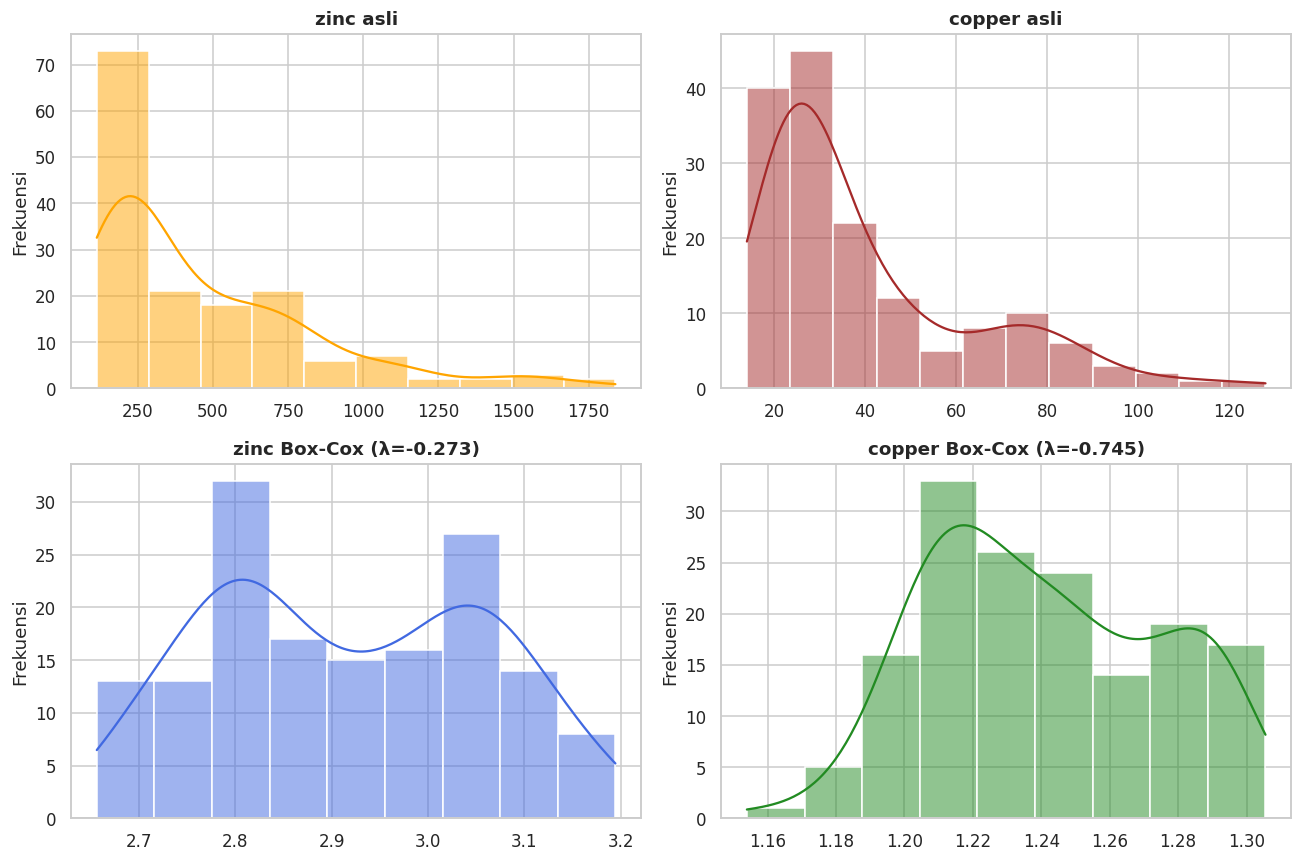

In [3]:
# Transformasi Box-Cox
df["t1"], lam1 = boxcox(df[VAR_PRIMER])
df["t2"], lam2 = boxcox(df[VAR_SEKUNDER])
print(f"Lambda Box-Cox {VAR_PRIMER}  : {lam1:.4f}")
print(f"Lambda Box-Cox {VAR_SEKUNDER}: {lam2:.4f}")

def inverse_boxcox(y, lam):
    y = np.asarray(y, float)
    if abs(lam) < 1e-12:
        return np.exp(y)
    return np.maximum(lam * y + 1.0, 1e-12) ** (1.0 / lam)

# Uji normalitas (Shapiro-Wilk) sebelum dan sesudah transformasi
print("\nUJI NORMALITAS SHAPIRO-WILK (p-value)")
for nama, asli, trans in [(VAR_PRIMER, VAR_PRIMER, "t1"), (VAR_SEKUNDER, VAR_SEKUNDER, "t2")]:
    print(f"  {nama:8s} asli: {shapiro(df[asli])[1]:.2e} | Box-Cox: {shapiro(df[trans])[1]:.2e}")

# Korelasi dua variabel
print("\nKORELASI ZINC-COPPER")
print(f"  Pearson  (asli)    : {pearsonr(df[VAR_PRIMER], df[VAR_SEKUNDER])[0]:.4f}")
print(f"  Spearman (asli)    : {spearmanr(df[VAR_PRIMER], df[VAR_SEKUNDER])[0]:.4f}")
print(f"  Pearson  (Box-Cox) : {pearsonr(df['t1'], df['t2'])[0]:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, kol, jud, w in [(axes[0,0], VAR_PRIMER, f"{VAR_PRIMER} asli", "orange"),
                        (axes[0,1], VAR_SEKUNDER, f"{VAR_SEKUNDER} asli", "brown"),
                        (axes[1,0], "t1", f"{VAR_PRIMER} Box-Cox (λ={lam1:.3f})", "royalblue"),
                        (axes[1,1], "t2", f"{VAR_SEKUNDER} Box-Cox (λ={lam2:.3f})", "forestgreen")]:
    sns.histplot(df[kol], kde=True, ax=ax, color=w)
    ax.set_title(jud, fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("Frekuensi")
plt.tight_layout(); plt.show()

coords = df[["x", "y"]].values.astype(float)
z1 = df["t1"].values
z2 = df["t2"].values
n = len(df)

## Interpretasi hasil transformasi dan hubungan Zinc-Copper

Hasil Box-Cox memberikan nilai lambda:
- Zinc = -0,2728
- Copper = -0,7454

Nilai lambda yang berada jauh dari 1 menunjukkan bahwa transformasi diperlukan untuk memperbaiki distribusi data.

Hasil korelasi menunjukkan:
- Pearson Zinc-Copper = 0,9083
- Spearman Zinc-Copper = 0,8994

Nilai korelasi positif yang tinggi menunjukkan bahwa Zinc dan Copper memiliki hubungan yang kuat. Hal ini mendukung penggunaan Copper sebagai variabel sekunder dalam metode co-kriging karena perubahan nilai Copper cenderung berkaitan dengan perubahan nilai Zinc.

## Transformasi Box-Cox

### Tujuan
Transformasi Box-Cox dilakukan untuk memperbaiki distribusi data apabila data asli belum memenuhi asumsi yang diperlukan dalam pemodelan geostatistik.

Transformasi ini membantu:
- mengurangi pengaruh nilai ekstrem,
- menstabilkan variasi data,
- membuat pola variogram lebih mudah dimodelkan.



## 2. Pemeriksaan tren dan anisotropi

### Tujuan
Tahap ini bertujuan mengetahui apakah data memiliki pola perubahan berdasarkan lokasi dan apakah hubungan spasial dipengaruhi oleh arah tertentu.

Pemeriksaan ini penting karena metode co-kriging menggunakan asumsi bahwa hubungan spasial antar titik dapat dijelaskan melalui struktur variogram.

### A. Pemeriksaan tren

Tren menunjukkan perubahan nilai yang sistematis berdasarkan koordinat lokasi.

### B. Pemeriksaan anisotropi

Anisotropi menunjukkan bahwa hubungan spasial tidak sama pada semua arah.

Jika pola mineralisasi memiliki arah tertentu, maka titik yang memiliki jarak sama tetapi arah berbeda dapat memiliki tingkat kemiripan yang berbeda.


Jarak maksimum antartitik: 4441 m | cutoff variogram: 1480 m

[Tren] R² regresi linear zinc (Box-Cox) terhadap x,y = 0.274
       (R² kecil -> asumsi rata-rata konstan relatif aman; R² besar -> pertimbangkan universal/regression kriging)
[Kovariat] Spearman zinc(Box-Cox) vs dist: -0.793
[Kovariat] Spearman zinc(Box-Cox) vs elev: -0.668
[Kovariat] Spearman zinc(Box-Cox) vs om: 0.647


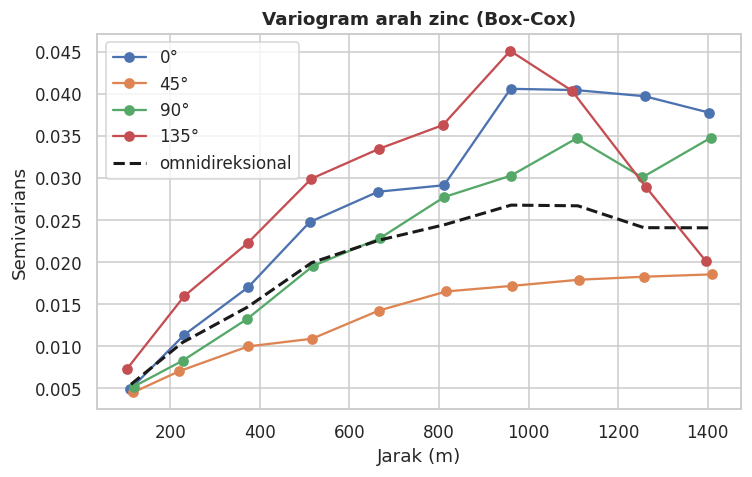

Jika kurva antararah berbeda nyata (terutama range-nya), pertimbangkan model anisotropi.


In [4]:
# Fungsi variogram eksperimental berbasis pasangan titik (tanpa pasangan dengan diri sendiri)
def pair_arrays(c):
    i, j = np.triu_indices(len(c), k=1)
    d = np.hypot(c[i, 0] - c[j, 0], c[i, 1] - c[j, 1])
    return i, j, d

def empirical_variogram(c, za, zb=None, n_lags=N_LAGS, cutoff=None, angle=None, tol=np.pi/8):
    """Semivarians (zb=None) atau variogram silang. Mengembalikan (h_rata2, gamma, jumlah_pasangan)."""
    i, j, d = pair_arrays(c)
    zb = za if zb is None else zb
    prod = (za[i] - za[j]) * (zb[i] - zb[j])
    keep = (d > 0) & (d <= cutoff)
    if angle is not None:                       # sudut 0 = Timur, berlawanan arah jarum jam
        ang = np.arctan2(c[j, 1] - c[i, 1], c[j, 0] - c[i, 0]) % np.pi
        sel = np.abs(ang - angle)
        sel = np.minimum(sel, np.pi - sel)
        keep &= sel <= tol
    edges = np.linspace(0, cutoff, n_lags + 1)
    idx = np.digitize(d, edges) - 1
    h = np.full(n_lags, np.nan); g = np.full(n_lags, np.nan); npr = np.zeros(n_lags)
    for k in range(n_lags):
        m = keep & (idx == k)
        npr[k] = m.sum()
        if npr[k] > 0:
            h[k] = d[m].mean()
            g[k] = 0.5 * prod[m].mean()
    return h, g, npr

max_dist = pdist(coords).max()
cutoff = max_dist * CUTOFF_FRAC
print(f"Jarak maksimum antartitik: {max_dist:.0f} m | cutoff variogram: {cutoff:.0f} m")

# (a) Tren linear terhadap koordinat
A = np.c_[np.ones(n), coords[:, 0] - coords[:, 0].mean(), coords[:, 1] - coords[:, 1].mean()]
beta, *_ = np.linalg.lstsq(A, z1, rcond=None)
r2_tren = 1 - np.sum((z1 - A @ beta) ** 2) / np.sum((z1 - z1.mean()) ** 2)
print(f"\n[Tren] R² regresi linear {VAR_PRIMER} (Box-Cox) terhadap x,y = {r2_tren:.3f}")
print("       (R² kecil -> asumsi rata-rata konstan relatif aman; R² besar -> pertimbangkan universal/regression kriging)")

# (b) Korelasi dengan kovariat lain bila tersedia (mis. dist = jarak ke sungai pada dataset Meuse)
for kov in ["dist", "elev", "om"]:
    if kov in df.columns and pd.api.types.is_numeric_dtype(df[kov]):
        print(f"[Kovariat] Spearman {VAR_PRIMER}(Box-Cox) vs {kov}: {spearmanr(df['t1'], df[kov].fillna(df[kov].median()))[0]:.3f}")

# (c) Variogram arah
plt.figure(figsize=(7, 4.5))
for deg in [0, 45, 90, 135]:
    h, g, _ = empirical_variogram(coords, z1, cutoff=cutoff, n_lags=10, angle=np.deg2rad(deg), tol=np.pi/8)
    plt.plot(h, g, "o-", label=f"{deg}°")
h, g, _ = empirical_variogram(coords, z1, cutoff=cutoff, n_lags=10)
plt.plot(h, g, "k--", lw=2, label="omnidireksional")
plt.xlabel("Jarak (m)"); plt.ylabel("Semivarians")
plt.title(f"Variogram arah {VAR_PRIMER} (Box-Cox)", fontweight="bold"); plt.legend(); plt.tight_layout(); plt.show()
print("Jika kurva antararah berbeda nyata (terutama range-nya), pertimbangkan model anisotropi.")

## Interpretasi hasil pemeriksaan tren dan anisotropi

Nilai R² regresi Zinc terhadap koordinat X dan Y sebesar 0,274. Nilai ini menunjukkan bahwa sebagian variasi Zinc dapat dijelaskan oleh posisi geografis, tetapi belum menunjukkan tren spasial yang sangat dominan.

Hubungan Zinc dengan beberapa kovariat menunjukkan:
- Jarak: korelasi Spearman -0,793
- Elevasi: korelasi Spearman -0,668
- Om: korelasi Spearman 0,647

Hasil tersebut menunjukkan adanya hubungan spasial dan lingkungan terhadap variasi Zinc.

Pemeriksaan arah perlu tetap dilakukan karena apabila pola variogram berbeda berdasarkan arah, maka anisotropi perlu dipertimbangkan dalam model.

### Catatan interpretasi struktur spasial

Pada tahap ini dilakukan pengamatan awal terhadap hubungan jarak antar titik dengan kemiripan nilai.

Variogram digunakan untuk melihat:
- bagaimana variasi data meningkat terhadap jarak,
- jarak pengaruh spasial (range),
- variasi lokal (nugget),
- total variasi yang dapat dijelaskan model (sill).

Hasil pemeriksaan ini menjadi dasar untuk pemodelan variogram pada tahap berikutnya.

## 3. Variogram dan pemodelan LMC

In [5]:
emp11 = empirical_variogram(coords, z1, cutoff=cutoff)
emp22 = empirical_variogram(coords, z2, cutoff=cutoff)
emp12 = empirical_variogram(coords, z1, z2, cutoff=cutoff)
EMP = [emp11, emp22, emp12]
print("Jumlah pasangan titik per kelas jarak:", emp11[2].astype(int))

def g_struct(h, a, kind):
    h = np.asarray(h, float)
    if kind == "spherical":
        r = np.minimum(h / a, 1.0)
        return 1.5 * r - 0.5 * r ** 3
    if kind == "exponential":
        return 1.0 - np.exp(-h / a)
    if kind == "gaussian":
        return 1.0 - np.exp(-(h / a) ** 2)
    raise ValueError(kind)

def eff_range(a, kind):
    return {"spherical": a, "exponential": 3 * a, "gaussian": np.sqrt(3) * a}[kind]

def chol_to_B(l):
    L = np.array([[l[0], 0.0], [l[1], l[2]]])
    return L @ L.T

def lmc_gamma_all(h, B0, B1, a, kind):
    """Mengembalikan (gamma11, gamma22, gamma12). Bernilai 0 tepat pada h = 0."""
    h = np.asarray(h, float)
    g = g_struct(h, a, kind)
    nug = (h > 0).astype(float)
    return tuple(B0[p, q] * nug + B1[p, q] * g for p, q in [(0, 0), (1, 1), (0, 1)])

def fit_lmc(emp, kind, cutoff):
    """Pencocokan WLS gabungan (bobot N(h)/h^2, dinormalkan per variogram). Mengembalikan (B0, B1, a, WSSE)."""
    skala = [np.nanmax(np.abs(e[1])) for e in emp]
    bobot = []
    for k, (h, gm, npr) in enumerate(emp):
        ok = ~np.isnan(gm)
        bobot.append(np.sqrt(npr[ok] / h[ok] ** 2) / skala[k])
    wmax = max(b.max() for b in bobot)
    bobot = [b / wmax for b in bobot]

    def resid(th):
        B0, B1, a = chol_to_B(th[0:3]), chol_to_B(th[3:6]), th[6]
        out = []
        for k, (h, gm, npr) in enumerate(emp):
            ok = ~np.isnan(gm)
            pred = lmc_gamma_all(h[ok], B0, B1, a, kind)[k]
            out.append(bobot[k] * (gm[ok] - pred))
        return np.concatenate(out)

    s11 = np.nanmean(emp[0][1][-4:]); s22 = np.nanmean(emp[1][1][-4:]); s12 = np.nanmean(emp[2][1][-4:])
    r1, r2 = np.sqrt(abs(s11)), np.sqrt(abs(s22))
    hasil = None
    for a0 in [0.25 * cutoff, 0.5 * cutoff, 0.8 * cutoff]:
        l11 = 0.9 ** 0.5 * r1
        l21 = 0.9 * s12 / l11
        l22 = np.sqrt(max(0.9 * s22 - l21 ** 2, 1e-10))
        x0 = np.array([0.2 * r1, 0.0, 0.2 * r2, l11, l21, l22, a0])
        lo = [0, -np.inf, 0, 0, -np.inf, 0, 0.05 * cutoff]
        hi = [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 3.0 * cutoff]
        try:
            r = least_squares(resid, x0, bounds=(lo, hi), x_scale=[r1, r2, r2, r1, r2, r2, 0.5 * cutoff])
        except Exception:
            continue
        if hasil is None or r.cost < hasil.cost:
            hasil = r
    th = hasil.x
    return chol_to_B(th[0:3]), chol_to_B(th[3:6]), th[6], 2 * hasil.cost

fits = {}
for kind in ["spherical", "exponential", "gaussian"]:
    fits[kind] = fit_lmc(EMP, kind, cutoff)

print("\nPERBANDINGAN MODEL (WSSE gabungan zinc + copper + silang)")
print("-" * 55)
for kind, (B0, B1, a, wsse) in fits.items():
    print(f"  {kind:12s} WSSE = {wsse:.3e} | range efektif = {eff_range(a, kind):7.1f} m")
best_kind = min(fits, key=lambda k: fits[k][3])
B0, B1, a_par, wsse_best = fits[best_kind]
print("-" * 55)
print(f"Model terbaik (WSSE terkecil): {best_kind.upper()}")

print("\nPARAMETER LMC MODEL TERPILIH")
nm = [f"{VAR_PRIMER}", f"{VAR_SEKUNDER}", "silang"]
idx_pair = [(0, 0), (1, 1), (0, 1)]
print(f"  {'komponen':10s} {'nugget':>12s} {'sill parsial':>14s} {'sill total':>12s} {'range efektif':>14s}")
for k, (p, q) in enumerate(idx_pair):
    print(f"  {nm[k]:10s} {B0[p,q]:12.3e} {B1[p,q]:14.3e} {B0[p,q]+B1[p,q]:12.3e} {eff_range(a_par, best_kind):13.1f} m")
rho_s = B1[0, 1] / np.sqrt(B1[0, 0] * B1[1, 1])
nug_berarti = (B0[0, 0] > 0.01 * (B0[0, 0] + B1[0, 0])) and (B0[1, 1] > 0.01 * (B0[1, 1] + B1[1, 1]))
rho_n = B0[0, 1] / np.sqrt(B0[0, 0] * B0[1, 1]) if nug_berarti else np.nan
print(f"\n  Korelasi komponen terstruktur (sill parsial) : {rho_s:.3f}")
print("  Korelasi komponen nugget                      : " + (f"{rho_n:.3f}" if nug_berarti else "tidak informatif (nugget salah satu variabel < 1% sill)"))
print(f"  Nisbah nugget/sill total ({VAR_PRIMER})            : {100*B0[0,0]/(B0[0,0]+B1[0,0]):.1f}%")
print(f"  Eigenvalue B0: {np.linalg.eigvalsh(B0).round(8)} | B1: {np.linalg.eigvalsh(B1).round(8)}  (semua >= 0 -> LMC valid)")

Jumlah pasangan titik per kelas jarak: [ 49 252 375 433 466 482 516 557 529 517 511 465 428 422 430]

PERBANDINGAN MODEL (WSSE gabungan zinc + copper + silang)
-------------------------------------------------------
  spherical    WSSE = 1.048e-08 | range efektif =   906.2 m
  exponential  WSSE = 2.395e-08 | range efektif =  1447.3 m
  gaussian     WSSE = 1.604e-08 | range efektif =   724.4 m
-------------------------------------------------------
Model terbaik (WSSE terkecil): SPHERICAL

PARAMETER LMC MODEL TERPILIH
  komponen         nugget   sill parsial   sill total  range efektif
  zinc          1.850e-03      2.320e-02    2.505e-02         906.2 m
  copper        2.404e-04      1.114e-03    1.355e-03         906.2 m
  silang        4.649e-04      4.827e-03    5.292e-03         906.2 m

  Korelasi komponen terstruktur (sill parsial) : 0.949
  Korelasi komponen nugget                      : 0.697
  Nisbah nugget/sill total (zinc)            : 7.4%
  Eigenvalue B0: [0.00011572 0.001

## Interpretasi hasil pemodelan variogram dan LMC

Perbandingan model menunjukkan:
- Spherical: WSSE = 1,048×10⁻⁸
- Exponential: WSSE = 2,395×10⁻⁸
- Gaussian: WSSE = 1,604×10⁻⁸

Model spherical dipilih karena memiliki nilai WSSE terkecil sehingga paling sesuai menggambarkan struktur spasial data.

Parameter model:
- Range efektif = 906,2 m

Artinya, titik pengamatan yang memiliki jarak kurang dari sekitar 906 meter masih memiliki hubungan spasial yang kuat.

Pada LMC diperoleh korelasi struktur spasial sebesar 0,949. Nilai ini menunjukkan hubungan spasial Zinc-Copper yang sangat kuat.

Nisbah nugget/sill Zinc sebesar 7,4% menunjukkan bahwa sebagian besar variasi Zinc dijelaskan oleh struktur spasial, sedangkan pengaruh variasi lokal relatif kecil.

Nilai eigenvalue positif menunjukkan bahwa model LMC memenuhi syarat validitas kovarians untuk co-kriging.

### Tujuan pemodelan variogram dan Linear Model of Coregionalization (LMC)

Dalam co-kriging, hubungan spasial tidak hanya dilihat pada variabel Zinc dan Copper secara terpisah, tetapi juga hubungan silang antar keduanya.

LMC digunakan agar:
1. Variogram Zinc,
2. Variogram Copper,
3. Cross-variogram Zinc-Copper

memiliki struktur kovarians yang konsisten.

### Interpretasi
- Nugget menunjukkan variasi kecil atau error pengukuran.
- Sill menunjukkan total variasi spasial.
- Range menunjukkan jarak dimana pengaruh spasial masih terlihat.
- Cross-variogram menggambarkan apakah Copper memberikan informasi tambahan untuk estimasi Zinc.

Hubungan silang yang baik mendukung penggunaan co-kriging dibanding hanya menggunakan kriging biasa.

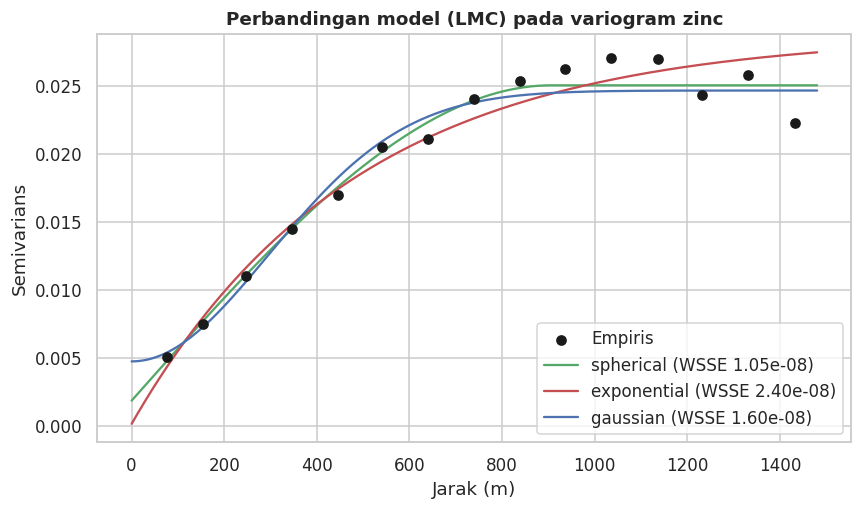

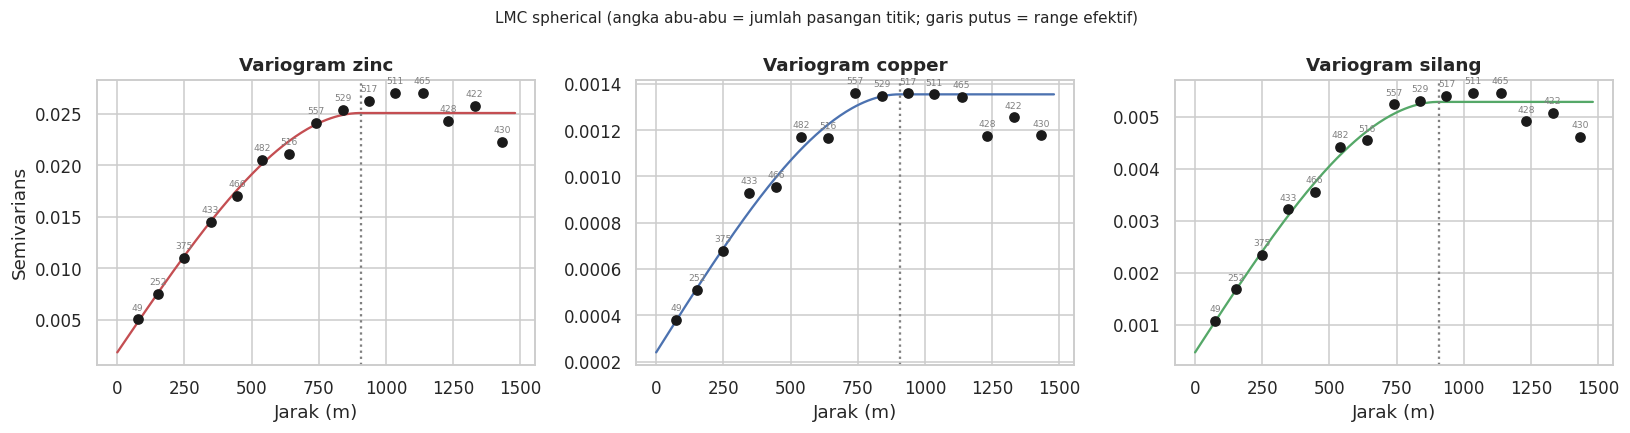

In [6]:
# Visualisasi 1: perbandingan tiga model pada variogram primer
hp = np.linspace(1e-6, cutoff, 200)
warna = {"spherical": "g", "exponential": "r", "gaussian": "b"}
plt.figure(figsize=(8, 4.8))
plt.scatter(emp11[0], emp11[1], c="k", zorder=5, label="Empiris")
for kind, (b0, b1, a, ws) in fits.items():
    plt.plot(hp, lmc_gamma_all(hp, b0, b1, a, kind)[0], color=warna[kind], label=f"{kind} (WSSE {ws:.2e})")
plt.title(f"Perbandingan model (LMC) pada variogram {VAR_PRIMER}", fontweight="bold")
plt.xlabel("Jarak (m)"); plt.ylabel("Semivarians"); plt.legend(); plt.tight_layout(); plt.show()

# Visualisasi 2: tiga komponen LMC model terpilih
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
g_fit = lmc_gamma_all(hp, B0, B1, a_par, best_kind)
for k, ax in enumerate(axes):
    h, g, npr = EMP[k]
    ax.scatter(h, g, c="k", zorder=5)
    ax.plot(hp, g_fit[k], color=["r", "b", "g"][k])
    for hh, gg, nn in zip(h, g, npr):
        if not np.isnan(gg):
            ax.annotate(int(nn), (hh, gg), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=6, color="gray")
    ax.axvline(eff_range(a_par, best_kind), color="gray", ls=":")
    ax.set_title(["Variogram " + VAR_PRIMER, "Variogram " + VAR_SEKUNDER, "Variogram silang"][k], fontweight="bold")
    ax.set_xlabel("Jarak (m)")
axes[0].set_ylabel("Semivarians")
plt.suptitle(f"LMC {best_kind} (angka abu-abu = jumlah pasangan titik; garis putus = range efektif)", fontsize=10)
plt.tight_layout(); plt.show()

## 4. Ordinary Co-Kriging

In [7]:
def build_K(c, B0, B1, a, kind):
    m = len(c)
    D = squareform(pdist(c))
    G11, G22, G12 = lmc_gamma_all(D, B0, B1, a, kind)    # diagonal otomatis 0
    K = np.zeros((2 * m + 2, 2 * m + 2))
    K[:m, :m], K[:m, m:2*m], K[m:2*m, :m], K[m:2*m, m:2*m] = G11, G12, G12.T, G22
    K[:m, 2*m] = 1.0;  K[2*m, :m] = 1.0           # kendala jumlah bobot primer = 1
    K[m:2*m, 2*m+1] = 1.0;  K[2*m+1, m:2*m] = 1.0   # kendala jumlah bobot sekunder = 0
    return K

def build_rhs(c, targets, B0, B1, a, kind):
    m, t = len(c), len(targets)
    dt = cdist(targets, c)
    g11, g22, g12 = lmc_gamma_all(dt, B0, B1, a, kind)
    R = np.zeros((2 * m + 2, t))
    R[:m] = g11.T
    R[m:2*m] = g12.T
    R[2*m] = 1.0
    return R

def cokrige(c, a1, a2, targets, B0, B1, a, kind):
    """Prediksi (skala Box-Cox) dan varians co-kriging untuk banyak titik target."""
    m = len(c)
    K = build_K(c, B0, B1, a, kind)
    R = build_rhs(c, targets, B0, B1, a, kind)
    try:
        W = solve(K, R)
    except LinAlgError:
        W = np.linalg.lstsq(K, R, rcond=None)[0]
    pred = W[:m].T @ a1 + W[m:2*m].T @ a2
    var = (W * R).sum(axis=0)
    return pred, np.maximum(var, 0.0)

K_full = build_K(coords, B0, B1, a_par, best_kind)
print(f"Ukuran sistem: {K_full.shape[0]} x {K_full.shape[1]} | kondisi numerik (cond): {np.linalg.cond(K_full):.2e}")

# Uji kebenaran: prediksi di titik sampel harus sama dengan data (interpolator eksak)
p_chk, v_chk = cokrige(coords, z1, z2, coords[:5], B0, B1, a_par, best_kind)
print("Uji interpolasi eksak (5 titik pertama) | selisih maks:", np.abs(p_chk - z1[:5]).max().round(10))

Ukuran sistem: 312 x 312 | kondisi numerik (cond): 1.17e+05
Uji interpolasi eksak (5 titik pertama) | selisih maks: 0.0


## Interpretasi sistem co-kriging

Sistem co-kriging memiliki ukuran matriks 312 × 312 dengan kondisi numerik sebesar 1,17×10⁵.

Uji interpolasi eksak menunjukkan selisih maksimum 0 pada lima titik awal, yang berarti model mampu mengembalikan nilai pengamatan pada lokasi yang diketahui.

Hal ini menunjukkan bahwa sistem persamaan co-kriging dapat berjalan dengan baik secara matematis.

### Tujuan ordinary co-kriging

Ordinary co-kriging digunakan untuk memperkirakan nilai Zinc pada lokasi yang tidak memiliki pengamatan langsung dengan memanfaatkan dua sumber informasi:

1. Nilai Zinc dari titik pengamatan sekitar.
2. Nilai Copper sebagai variabel pendukung.
3. Hubungan spasial yang diperoleh dari model LMC.

### Interpretasi
Nilai estimasi merupakan hasil kombinasi berbobot dari data sekitar. Bobot tidak hanya ditentukan oleh jarak, tetapi juga oleh hubungan spasial antar variabel.

Semakin kuat hubungan spasial Zinc-Copper, semakin besar kontribusi variabel sekunder dalam proses estimasi.

## 5. Validasi silang LOOCV

HASIL LOOCV (refit per lipatan: False)
           Skala Box-Cox  Skala asli (ppm)
RMSE              0.0766          229.5255
MAE               0.0575          141.0129
ME (bias)         0.0003          -52.2564
R²                0.7101            0.6065

GALAT TERSTANDAR (skala Box-Cox)
  Rata-rata : -0.002   (ideal ~ 0)
  Varians   : 0.832   (ideal ~ 1; >1 = ketidakpastian diremehkan, <1 = dibesar-besarkan)
  Cakupan interval 95% : 96.1%   (ideal ~ 95%)
Catatan: lambda Box-Cox tetap dihitung dari seluruh data; transformasi balik sederhana cenderung mendekati median (bias kecil).


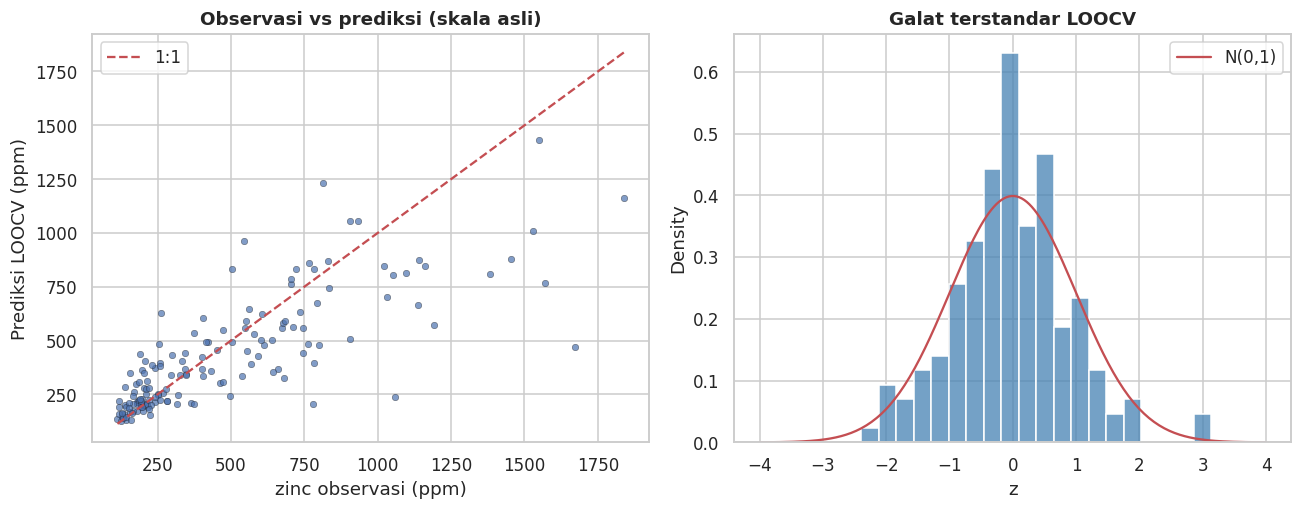

In [8]:
def fit_params_subset(c_sub, a1_sub, a2_sub):
    """Estimasi ulang LMC (tipe model tetap = best_kind) hanya dari data lipatan latih."""
    cut = pdist(c_sub).max() * CUTOFF_FRAC
    e = [empirical_variogram(c_sub, a1_sub, cutoff=cut),
         empirical_variogram(c_sub, a2_sub, cutoff=cut),
         empirical_variogram(c_sub, a1_sub, a2_sub, cutoff=cut)]
    return fit_lmc(e, best_kind, cut)[:3]

pred_t = np.zeros(n); var_t = np.zeros(n)
for i in range(n):
    tr = np.ones(n, bool); tr[i] = False
    if REFIT_PER_FOLD:
        b0_i, b1_i, a_i = fit_params_subset(coords[tr], z1[tr], z2[tr])
    else:
        b0_i, b1_i, a_i = B0, B1, a_par
    p, v = cokrige(coords[tr], z1[tr], z2[tr], coords[i:i+1], b0_i, b1_i, a_i, best_kind)
    pred_t[i], var_t[i] = p[0], v[0]

obs_ppm  = df[VAR_PRIMER].values
pred_ppm = inverse_boxcox(pred_t, lam1)

def metrik(obs, pred):
    e = pred - obs
    return {"RMSE": np.sqrt(np.mean(e**2)), "MAE": np.mean(np.abs(e)), "ME (bias)": np.mean(e),
            "R²": 1 - np.sum(e**2) / np.sum((obs - obs.mean())**2)}

tab = pd.DataFrame({"Skala Box-Cox": metrik(z1, pred_t), "Skala asli (ppm)": metrik(obs_ppm, pred_ppm)})
print(f"HASIL LOOCV (refit per lipatan: {REFIT_PER_FOLD})")
print(tab.round(4).to_string())

zs = (z1 - pred_t) / np.sqrt(np.maximum(var_t, 1e-12))
print("\nGALAT TERSTANDAR (skala Box-Cox)")
print(f"  Rata-rata : {zs.mean():.3f}   (ideal ~ 0)")
print(f"  Varians   : {zs.var(ddof=1):.3f}   (ideal ~ 1; >1 = ketidakpastian diremehkan, <1 = dibesar-besarkan)")
print(f"  Cakupan interval 95% : {100*np.mean(np.abs(zs) <= 1.96):.1f}%   (ideal ~ 95%)")
print("Catatan: lambda Box-Cox tetap dihitung dari seluruh data; transformasi balik sederhana cenderung mendekati median (bias kecil).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.scatter(obs_ppm, pred_ppm, s=18, alpha=0.7, edgecolor="k", linewidth=0.3)
lim = [min(obs_ppm.min(), pred_ppm.min()), max(obs_ppm.max(), pred_ppm.max())]
ax.plot(lim, lim, "r--", label="1:1"); ax.set_xlabel(f"{VAR_PRIMER} observasi (ppm)"); ax.set_ylabel("Prediksi LOOCV (ppm)")
ax.set_title("Observasi vs prediksi (skala asli)", fontweight="bold"); ax.legend()
ax = axes[1]
sns.histplot(zs, stat="density", bins=20, ax=ax, color="steelblue")
xs = np.linspace(-4, 4, 200); ax.plot(xs, norm.pdf(xs), "r-", label="N(0,1)")
ax.set_title("Galat terstandar LOOCV", fontweight="bold"); ax.set_xlabel("z"); ax.legend()
plt.tight_layout(); plt.show()

## Interpretasi hasil validasi silang LOOCV

Hasil validasi menunjukkan:

Pada skala Box-Cox:
- RMSE = 0,0766
- MAE = 0,0575
- ME = 0,0003
- R² = 0,7101

Pada skala asli:
- RMSE = 229,53 ppm
- MAE = 141,01 ppm
- ME = -52,26 ppm
- R² = 0,6065

Nilai ME pada skala transformasi yang mendekati nol menunjukkan model tidak mengalami bias yang besar.

Nilai R² sebesar 0,6065 pada skala asli menunjukkan bahwa model mampu menjelaskan sebagian besar variasi spasial Zinc.

Cakupan interval 95% sebesar 96,1% mendekati nilai ideal 95%, sehingga ketidakpastian model dapat dianggap cukup baik.

### Tujuan validasi silang

Validasi silang dilakukan untuk mengetahui apakah model co-kriging mampu melakukan prediksi pada lokasi yang sebenarnya sudah diketahui.

Metode LOOCV menghilangkan satu titik pengamatan kemudian memperkirakan kembali nilai tersebut menggunakan titik lainnya.

### Interpretasi hasil
Parameter yang diperhatikan:

- Mean Error (ME)
  - mendekati 0 menunjukkan model tidak mengalami bias.

- Root Mean Square Error (RMSE)
  - menunjukkan besar rata-rata kesalahan prediksi.
  - nilai lebih kecil menunjukkan hasil prediksi lebih mendekati data pengamatan.

Validasi digunakan untuk memastikan model tidak hanya cocok secara matematis, tetapi juga memiliki kemampuan prediksi yang baik.

## 6. Peta estimasi dan ketidakpastian

Sel grid aktif: 2179 dari 4900 (convex hull dan jarak <= 300 m dari sampel)


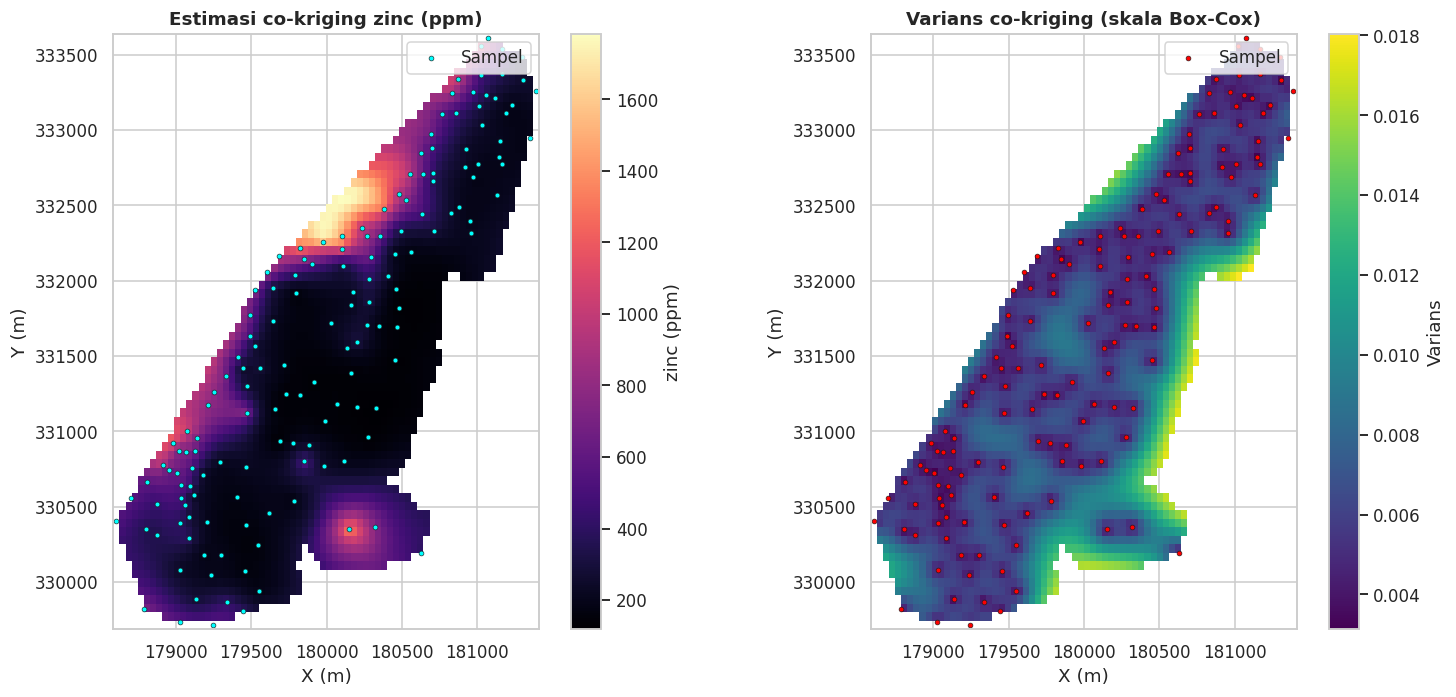

Rentang estimasi di peta: 118 - 1783 ppm | rentang varians: 3.13e-03 - 1.80e-02


In [9]:
gx = np.linspace(coords[:, 0].min(), coords[:, 0].max(), GRID_N)
gy = np.linspace(coords[:, 1].min(), coords[:, 1].max(), GRID_N)
GX, GY = np.meshgrid(gx, gy)
pts = np.c_[GX.ravel(), GY.ravel()]

dalam_hull = Delaunay(coords).find_simplex(pts) >= 0
dekat = cdist(pts, coords).min(axis=1) <= MASK_DIST
aktif = dalam_hull & dekat
print(f"Sel grid aktif: {aktif.sum()} dari {len(pts)} (convex hull dan jarak <= {MASK_DIST} m dari sampel)")

pt = np.full(len(pts), np.nan); vt = np.full(len(pts), np.nan)
pt[aktif], vt[aktif] = cokrige(coords, z1, z2, pts[aktif], B0, B1, a_par, best_kind)
peta_ppm = np.ma.masked_invalid(inverse_boxcox(pt, lam1).reshape(GX.shape))
peta_var = np.ma.masked_invalid(vt.reshape(GX.shape))

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
m1 = axes[0].pcolormesh(GX, GY, peta_ppm, cmap="magma", shading="auto")
axes[0].scatter(coords[:, 0], coords[:, 1], c="cyan", s=10, edgecolor="k", linewidth=0.4, label="Sampel")
axes[0].set_title(f"Estimasi co-kriging {VAR_PRIMER} (ppm)", fontweight="bold")
fig.colorbar(m1, ax=axes[0], label=f"{VAR_PRIMER} (ppm)")
m2 = axes[1].pcolormesh(GX, GY, peta_var, cmap="viridis", shading="auto")
axes[1].scatter(coords[:, 0], coords[:, 1], c="red", s=10, edgecolor="k", linewidth=0.4, label="Sampel")
axes[1].set_title("Varians co-kriging (skala Box-Cox)", fontweight="bold")
fig.colorbar(m2, ax=axes[1], label="Varians")
for ax in axes:
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_aspect("equal"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()
print(f"Rentang estimasi di peta: {peta_ppm.min():.0f} - {peta_ppm.max():.0f} ppm | rentang varians: {peta_var.min():.2e} - {peta_var.max():.2e}")

## Interpretasi hasil peta estimasi

Area prediksi aktif sebanyak 2179 sel dari 4900 grid. Pembatasan ini dilakukan agar estimasi hanya dilakukan pada area yang memiliki dukungan data pengamatan.

Rentang estimasi Zinc pada peta:
- Minimum = 118 ppm
- Maksimum = 1783 ppm

Rentang varians estimasi:
- 3,13×10⁻³ hingga 1,80×10⁻²

Daerah dengan nilai estimasi tinggi menunjukkan zona dengan kemungkinan kandungan Zinc lebih besar berdasarkan hubungan spasial data Zinc dan informasi Copper.

Nilai varians yang lebih tinggi menunjukkan lokasi dengan tingkat ketidakpastian lebih besar.

### Tujuan pemetaan hasil co-kriging

Peta hasil digunakan untuk menggambarkan distribusi spasial Zinc berdasarkan model co-kriging.

### Interpretasi
- Peta estimasi menunjukkan pola persebaran nilai Zinc pada lokasi yang tidak diamati.
- Peta standar error menunjukkan tingkat ketidakpastian prediksi.
- Area dengan error tinggi menunjukkan daerah yang memiliki informasi spasial lebih terbatas.

Interpretasi akhir sebaiknya menggunakan hasil yang telah dilakukan back transformation agar kembali ke satuan asli.

## 7. Ringkasan hasil

In [11]:
print("=" * 60)
print("RINGKASAN HASIL")
print("=" * 60)
print(f"N sampel                  : {n}")
print(f"Lambda Box-Cox            : {VAR_PRIMER} = {lam1:.4f} ; {VAR_SEKUNDER} = {lam2:.4f}")
print(f"Model variogram terpilih  : {best_kind} (WSSE = {wsse_best:.3e})")
print(f"Range efektif             : {eff_range(a_par, best_kind):.1f} m")
print(f"Nugget  (B0) 11/22/12     : {B0[0,0]:.3e} / {B0[1,1]:.3e} / {B0[0,1]:.3e}")
print(f"Sill parsial (B1) 11/22/12: {B1[0,0]:.3e} / {B1[1,1]:.3e} / {B1[0,1]:.3e}")
print(f"Korelasi struktur spasial : {rho_s:.3f}")
print(f"R² tren linear terhadap x,y: {r2_tren:.3f}")
print(f"LOOCV Box-Cox  : RMSE={tab.loc['RMSE','Skala Box-Cox']:.4f}  MAE={tab.loc['MAE','Skala Box-Cox']:.4f}  R²={tab.loc['R²','Skala Box-Cox']:.4f}")
print(f"LOOCV ppm      : RMSE={tab.loc['RMSE','Skala asli (ppm)']:.2f}  MAE={tab.loc['MAE','Skala asli (ppm)']:.2f}  R²={tab.loc['R²','Skala asli (ppm)']:.4f}")
print(f"Galat terstandar: rata-rata={zs.mean():.3f}, varians={zs.var(ddof=1):.3f}, cakupan 95%={100*np.mean(np.abs(zs)<=1.96):.1f}%")

RINGKASAN HASIL
N sampel                  : 155
Lambda Box-Cox            : zinc = -0.2728 ; copper = -0.7454
Model variogram terpilih  : spherical (WSSE = 1.048e-08)
Range efektif             : 906.2 m
Nugget  (B0) 11/22/12     : 1.850e-03 / 2.404e-04 / 4.649e-04
Sill parsial (B1) 11/22/12: 2.320e-02 / 1.114e-03 / 4.827e-03
Korelasi struktur spasial : 0.949
R² tren linear terhadap x,y: 0.274
LOOCV Box-Cox  : RMSE=0.0766  MAE=0.0575  R²=0.7101
LOOCV ppm      : RMSE=229.53  MAE=141.01  R²=0.6065
Galat terstandar: rata-rata=-0.002, varians=0.832, cakupan 95%=96.1%


## Kesimpulan hasil analisis co-kriging

Berdasarkan seluruh tahapan analisis:

1. Data terdiri dari 155 titik pengamatan dengan variasi kandungan Zinc dan Copper yang cukup tinggi.
2. Zinc dan Copper memiliki korelasi positif yang kuat sehingga Copper sesuai digunakan sebagai variabel sekunder.
3. Model variogram terbaik adalah spherical dengan range efektif 906,2 meter.
4. Model LMC menunjukkan hubungan spasial Zinc-Copper yang kuat dengan korelasi struktur 0,949.
5. Validasi LOOCV menghasilkan R² sebesar 0,6065 pada skala asli.
6. Hasil estimasi telah dikembalikan ke skala asli melalui back transformation sehingga dapat digunakan untuk interpretasi distribusi Zinc.

Dengan demikian, metode ordinary co-kriging mampu memanfaatkan hubungan spasial Zinc-Copper untuk menghasilkan estimasi kandungan Zinc pada lokasi yang tidak memiliki pengamatan langsung.

### Interpretasi umum hasil analisis

Analisis co-kriging dianggap memberikan hasil yang baik apabila:

1. Data memiliki struktur spasial yang dapat dijelaskan melalui variogram.
2. Hubungan Zinc dan Copper dapat dijelaskan melalui cross-variogram.
3. Model LMC mampu merepresentasikan hubungan antar variabel.
4. Hasil validasi menunjukkan kesalahan prediksi yang dapat diterima.
5. Hasil akhir dapat ditampilkan kembali pada skala data asli melalui back transformation.

Dengan demikian, hasil akhir tidak hanya berupa nilai estimasi, tetapi juga informasi mengenai pola spasial dan tingkat ketidakpastian.

## 8. Back Transformation (mengembalikan ke skala data asli)

### Tujuan
Karena pemodelan dilakukan menggunakan data hasil transformasi Box-Cox, nilai estimasi co-kriging masih berada pada skala transformasi.

Back transformation dilakukan agar hasil akhir dapat:
- dibandingkan dengan data pengamatan asli,
- digunakan dalam interpretasi kandungan unsur,
- ditampilkan dalam peta dengan satuan sebenarnya.

### Interpretasi
Hasil sebelum transformasi balik digunakan untuk evaluasi model, sedangkan hasil setelah transformasi balik digunakan untuk interpretasi spasial akhir.

Tahap ini menjadi bagian penting agar keluaran analisis dapat diterapkan pada kondisi lapangan.

In [13]:
# Back transformation Box-Cox

import numpy as np

def inverse_boxcox(y, lam):
    if lam == 0:
        return np.exp(y)
    else:
        return np.power(lam * y + 1, 1 / lam)

# Contoh:
# z_pred_asli = inverse_boxcox(z_pred_transform, lambda_zinc)

# Simpan hasil estimasi pada skala asli
# hasil['Zinc_pred_asli'] = z_pred_asli
